In [1]:
import os
import yaml
import copy

import numpy as np
import pandas as pd
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

AnEn format
```
/glade/campaign/ral/nsap/alessand/STUDIES/India_polluted/input_anen.nc
```

## Collect ERA5 from ARCO

In [3]:
dict_loc = {
    'Pituffik': (76.4, -68.575),
    'Fairbanks': (64.75, -147.4),
    'Guam': (13.475, 144.75),
    'Yuma_PG': (33.125, -114.125),
    'Fort_Bragg': (35.05, -79.115),
}

In [4]:
year = 1958

varnames = [
    '2m_temperature',
    '2m_dewpoint_temperature',
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    'total_precipitation',
    'minimum_2m_temperature_since_previous_post_processing', 
    'maximum_2m_temperature_since_previous_post_processing', 
    'surface_solar_radiation_downwards'
]

ERA5_1h = xr.open_zarr(
    "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
    chunks=None,
    storage_options=dict(token='anon'),)[varnames]

ERA5_select = ERA5_1h.sel(time=slice(f'{year}-01-01T00', f'{year}-12-31T23'))

ERA5_select = ERA5_select.assign_coords(longitude = (((ERA5_select.longitude + 180) % 360) - 180))
ERA5_select = ERA5_select.sortby("longitude")

In [33]:
ERA5_select['total_precipitation']

<xarray.DataArray 'total_precipitation' (time: 8760, latitude: 721,
                                         longitude: 1440)> Size: 36GB
[9094982400 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 70kB 1958-01-01 ... 1958-12-31T23:00:00
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Attributes:
    long_name:   Total precipitation
    short_name:  tp
    units:       m

In [23]:
1000*ERA5_select['total_precipitation'].sel(latitude=76.4, longitude=-68.575, method='nearest').values.sum()

207.83114433288574

In [27]:
ds = xr.open_dataset('/glade/derecho/scratch/ksha/EPRI_data/METRICS/STN_ERA5_ALL_20260604.zarr')

In [35]:
ds = xr.open_dataset('/glade/derecho/scratch/ksha/EPRI_AnEn/input_AnEn_ERA5_20260221.nc')

In [42]:
np.median(ds['ERA5_precip_mean'].isel(site=0, lead_time=0,).values)

0.9157376

In [43]:
0.9*365

328.5

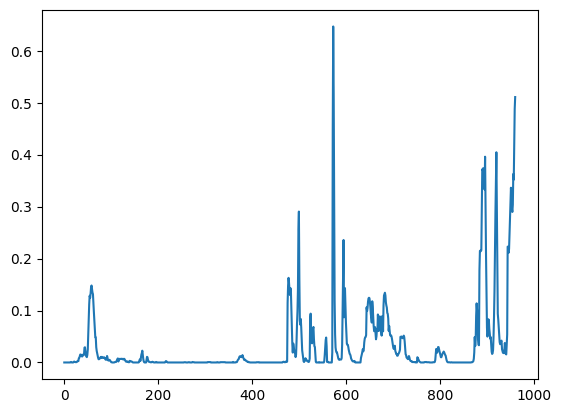

In [22]:
plt.plot(1000*ERA5_select['total_precipitation'].sel(latitude=76.4, longitude=-68.575, method='nearest').values.sum())

In [7]:
save_name = '/glade/campaign/ral/hap/ksha/EPRI_data/ERA5_hourly/{}_{}.zarr'

for stn, (lat_mid, lon_mid) in dict_loc.items():
    
    subset = ERA5_select.sel(latitude=lat_mid, longitude=lon_mid, method='nearest')
    
    save_name_ = save_name.format(stn, year)
    subset.to_zarr(save_name_, mode='w')
    print(f'Save to {save_name_}')

Save to /glade/campaign/ral/hap/ksha/EPRI_data/ERA5_hourly/Pituffik_1958.zarr
Save to /glade/campaign/ral/hap/ksha/EPRI_data/ERA5_hourly/Fairbanks_1958.zarr
Save to /glade/campaign/ral/hap/ksha/EPRI_data/ERA5_hourly/Guam_1958.zarr
Save to /glade/campaign/ral/hap/ksha/EPRI_data/ERA5_hourly/Yuma_PG_1958.zarr
Save to /glade/campaign/ral/hap/ksha/EPRI_data/ERA5_hourly/Fort_Bragg_1958.zarr
